# Correlation Heatmap:

----

# Import Libraries:

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import * 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, count
from pyspark.sql.types import DoubleType
import os

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("correlation_heatmap")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.network.timeout", "600s")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.rpc.askTimeout", "600s")
    .config("spark.driver.memory", "100G")
    .config("spark.executor.memory", "100G")
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.sql.debug.maxToStringFields", "1000")
    .getOrCreate()
)

24/08/21 17:52:43 WARN Utils: Your hostname, Cocos-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 172.16.33.67 instead (on interface en0)
24/08/21 17:52:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/21 17:52:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/08/21 17:52:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Read Files:

In [3]:
base_dir = "../data"
plot_path = '../plots'

Sampled full HVFHV and weather dataset:

In [4]:
final_path = base_dir + '/developed/final_data'
final_sdf = spark.read.parquet(final_path)
final_sdf.show(5)

+-----+-----------+--------------------+------------------+------------------+-----------------------+---------------------+-------------------+------------------+------------------+------------------------+---------------+-------------------+------------------+-----------------------+---------------------+--------------------+-------------------+-----------------------------+-------------------+------------------+--------+-------------+----------------------+-------------------+------------------+--------------------+-----------------+----------------+----------------+---------------+---------------+----------------+----------------+---------------+---------------+----------------+----------------+---------------+----------------+----------------+----------------+----------------+---------------+----------------+----------------+----------------+---------------+---------------+----------------+----------------+---------------+---------------+---------------+---------------+-----------

In [5]:
final_sdf.printSchema()

root
 |-- month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- avg_utilization_rate: double (nullable = true)
 |-- avg_trip_miles: double (nullable = true)
 |-- avg_trip_time: double (nullable = true)
 |-- avg_base_passenger_fare: double (nullable = true)
 |-- avg_total_fare_amount: double (nullable = true)
 |-- avg_tolls: double (nullable = true)
 |-- avg_bcf: double (nullable = true)
 |-- avg_sales_tax: double (nullable = true)
 |-- avg_congestion_surcharge: double (nullable = true)
 |-- avg_airport_fee: double (nullable = true)
 |-- avg_tips: double (nullable = true)
 |-- avg_driver_pay: double (nullable = true)
 |-- avg_shared_request_flag: double (nullable = true)
 |-- avg_shared_match_flag: double (nullable = true)
 |-- avg_wav_request_flag: double (nullable = true)
 |-- avg_wav_match_flag: double (nullable = true)
 |-- avg_request_to_pickup_minutes: double (nullable = true)
 |-- avg_trip_speed: double (nullable = true)
 |-- avg_total_revenue: double 

# Correlation Heatmaps:

24/08/21 17:53:02 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


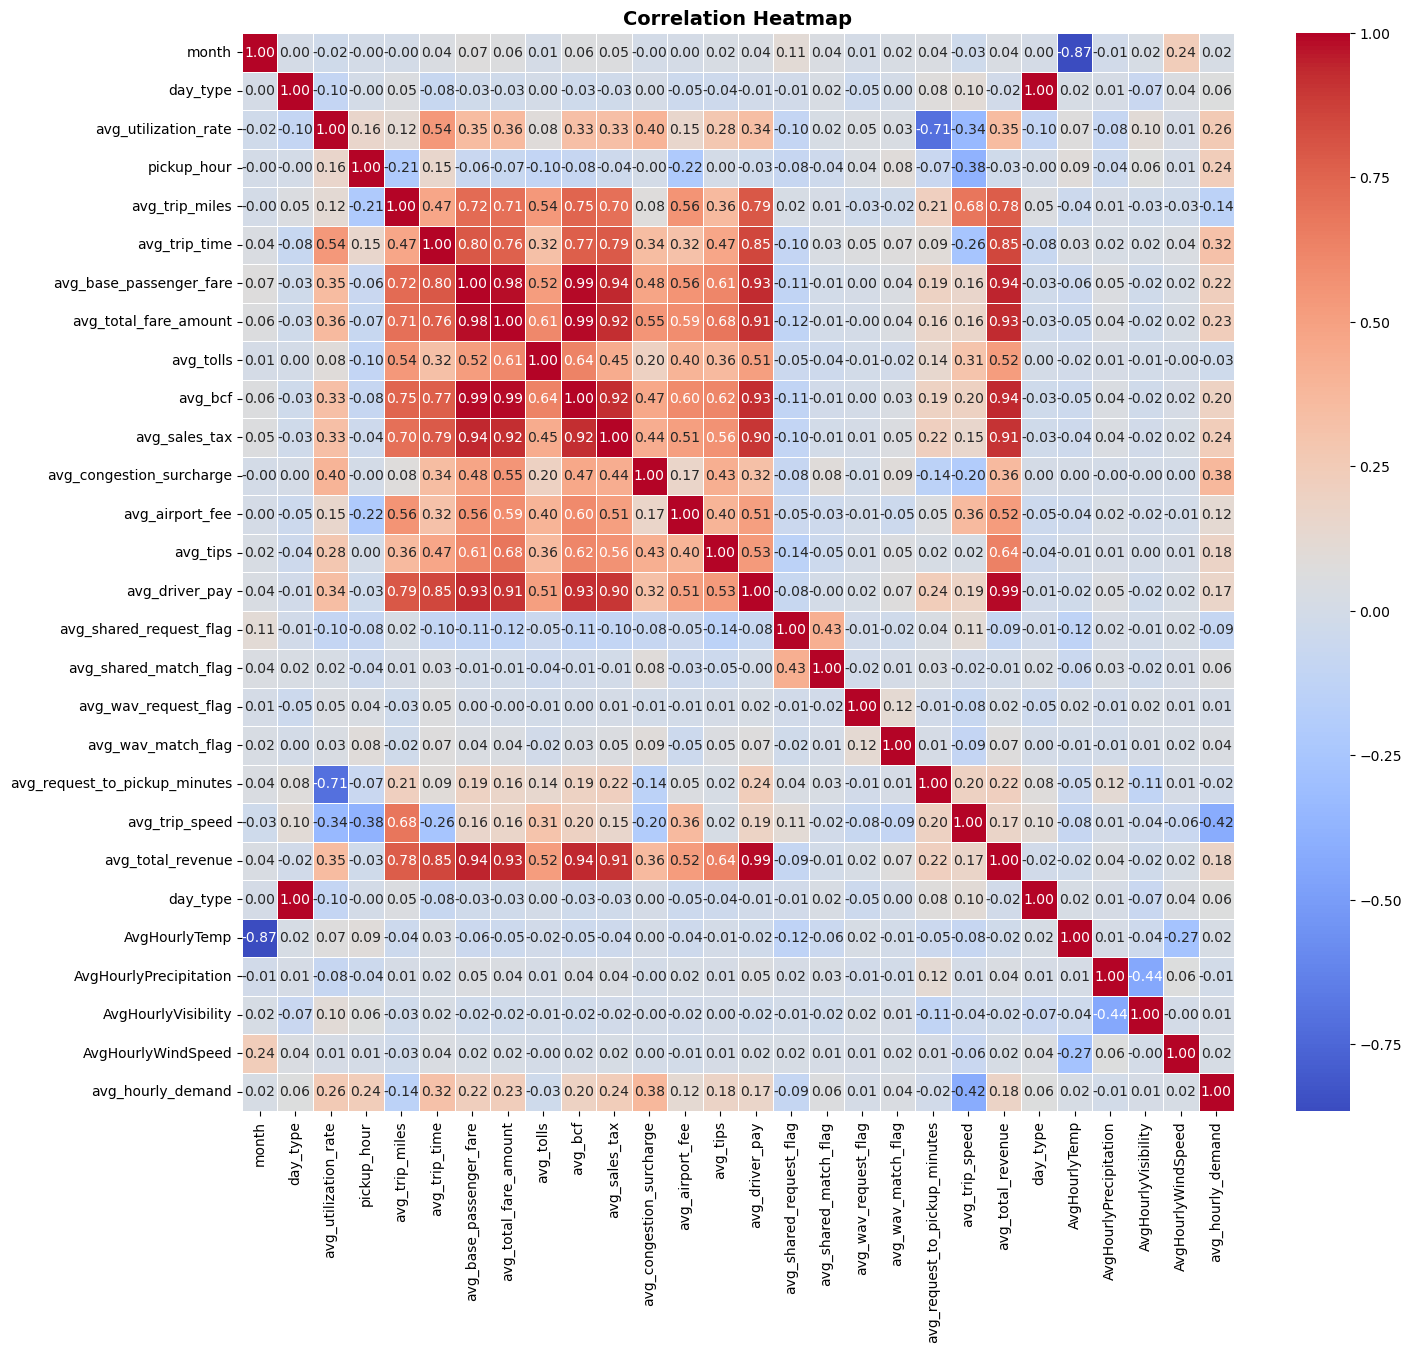

In [6]:
CORR_COLS = [
    "month", "day_type", "avg_utilization_rate", "pickup_hour", "avg_trip_miles", "avg_trip_time", 
    "avg_base_passenger_fare", "avg_total_fare_amount", "avg_tolls",
    "avg_bcf", "avg_sales_tax", "avg_congestion_surcharge", 
    "avg_airport_fee", "avg_tips", "avg_driver_pay", 
    "avg_shared_request_flag", "avg_shared_match_flag", 
    "avg_wav_request_flag", "avg_wav_match_flag", 
    "avg_request_to_pickup_minutes", "avg_trip_speed", "avg_total_revenue",
    "day_type", "AvgHourlyTemp", "AvgHourlyPrecipitation", 
    "AvgHourlyVisibility", "AvgHourlyWindSpeed", "avg_hourly_demand"
             ]

# Assemble the features into a single vector column
features = "correlation_features"
assembler = VectorAssembler(
    inputCols=CORR_COLS,
    outputCol=features
)

# Transform the DataFrame and compute the correlation matrix
feature_vector = assembler \
                .transform(final_sdf.dropna('any')) \
                .select(features)

corr_matrix_dense = Correlation.corr(feature_vector, features).head()[0]

# Convert to numpy array and then to pandas DataFrame for easier handling
corr_matrix = corr_matrix_dense.toArray()
df_corr = pd.DataFrame(corr_matrix, index=CORR_COLS, columns=CORR_COLS)

# Plot
plt.figure(figsize=(16, 14))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Correlation Heatmap', weight='bold', fontsize=14)

# Save and display the plot
file_name = 'correlation_heatmap_in_final_data.png'

file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

Remove some reatures:
- Since `avg_shared_request_flag`, `avg_shared_match_flag`, `avg_wav_request_flag`, `avg_wav_match_flag`, `avg_request_to_pickup_minutes` has low correlation with `avg_total_revenue` and `avg_hourly_demand`, we will not include them when buildinging models.
- Since `avg_utilization_rate` is calculated by `avg_trip_time`/(`avg_request_to_pickup_minutes`+`avg_trip_time`), we will not include `avg_request_to_pickup_minutes` and `avg_trip_time` in the model.
- Since `avg_total_revenue` has already include `avg_driver_pay` and `avg_tips`, we will remove them.
- Since `avg_total_fare_amount` has already includes `avg_base_passenger_fare`, `avg_tips`, `avg_tolls`, `avg_sales_tax`, `avg_congestion_fee`, `airport_fee`, we will not include them in the model.
- Although `avg_total_fare_amount` includes `avg_bcf`, we keep it since drivers will get part of black car fund and `avg_total_revenue` does not include it.
- Since `AvgHourlyPrecipitation`, `AvgHourlyVisibility` and `AvgHourlyWindSpeed` has low correlation with `avg_total_revenue` and `avg_hourly_demand`, we will not include them when buildinging models.

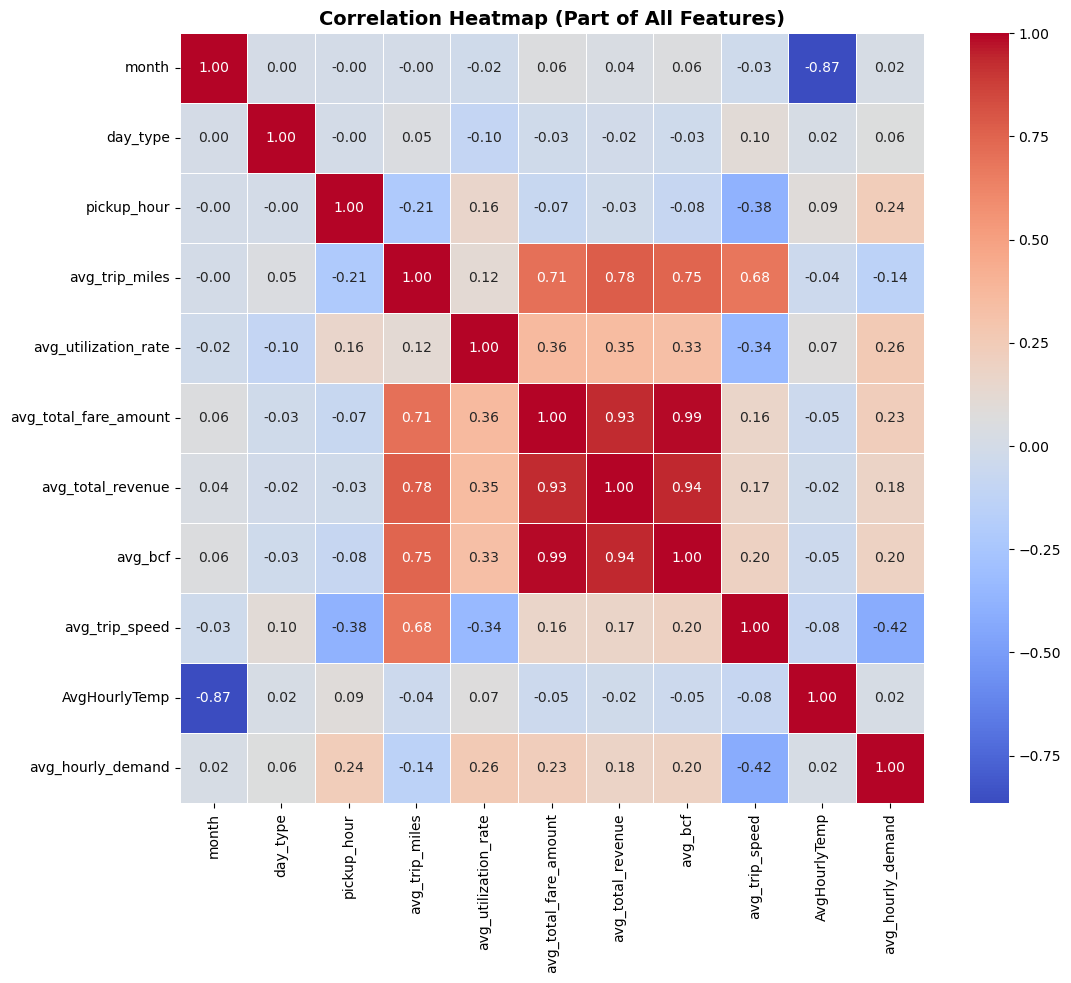

In [7]:
CORR_COLS = [
    "month", "day_type", "pickup_hour", "avg_trip_miles", "avg_utilization_rate", 
    "avg_total_fare_amount", "avg_total_revenue",
    "avg_bcf", "avg_trip_speed", "AvgHourlyTemp", "avg_hourly_demand"
            ]

# Assemble the features into a single vector column
features = "correlation_features"
assembler = VectorAssembler(
    inputCols=CORR_COLS,
    outputCol=features
)

# Transform the DataFrame and compute the correlation matrix
feature_vector = assembler \
                .transform(final_sdf.dropna('any')) \
                .select(features)

corr_matrix_dense = Correlation.corr(feature_vector, features).head()[0]

# Convert to numpy array and then to pandas DataFrame for easier handling
corr_matrix = corr_matrix_dense.toArray()
df_corr = pd.DataFrame(corr_matrix, index=CORR_COLS, columns=CORR_COLS)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Correlation Heatmap (Part of All Features)', weight='bold', fontsize=14)

# Save and display the plot
file_name = 'correlation_heatmap_in_selected_final_data.png'

file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

Thus, the attibutes in models are: month, day_type, pickup_hour, avg_trip_miles, avg_utilization_rate, avg_total_fare_amount, avg_bcf, avg_trip_speed, avg_total_revenue, AvgHourlyTemp, avg_hourly_demand, PULocationID after one-hot encoding, service_zone after one-hot encoding, zone after one-hot encoding, borough after one-hot encoding, and building_class after one-hot encoding.